# Lab 5: Foot Pose Detection via Temporal Segmentation

## Learning Objectives

1. **Dynamic Cross-Validation**: Understand and implement a validation strategy adapted to small datasets
2. **U-Net 1D**: Classic encoder-decoder with skip connections for 1D signal segmentation
3. **Bidirectional GRU**: Recurrent approach for sequential segmentation
4. **SETR Architecture** (SEgmentation TRansformer): Discover Transformers applied to sequence segmentation
5. **LoRA Fine-Tuning**: Subject-specific adaptation with Low-Rank Adaptation

---
## 1. Context: Motion Analysis for Multiple Sclerosis

### Medical Problem

In the context of motion analysis for **patients with Multiple Sclerosis (MS)**, patients are asked to walk a few steps in a room equipped with several **high-resolution cameras** (framerate 100Hz).

**Black markers** are placed on the leg joints of the subjects, which allows obtaining the **3D coordinates** of each marker over time through a motion capture system.

### Clinical Objective

To analyze movement, a crucial first step is to **precisely locate the instants of foot lift-off and foot strike** (left and right).

Traditionally, this task is performed by a **human expert**, which is:
- **Time-consuming** (several hours for a single patient)
- **Subject to inter-annotator variability**
- **Not scalable** for large-scale studies

### Available Dataset

We have a dataset of **10 subjects** who each perform **10 trials** (some trials may be rejected for two of the subjects). An expert manually annotated the foot strike events.

**Inputs (X)**: 3D coordinates of 20 sensors × 3 axes = **60 features** per time step

**Outputs (Y)**: 2 binary signals indicating whether the foot (left/right) is on the ground (0) or lifted (1)

---
### 3D Visualization of Motion Capture Data (Informational)

To better understand what the data looks like, the following cell launches an **interactive 3D viewer** of the motion capture markers for a single trial. This is not a question — it's here to help you visualize the marker trajectories in 3D space.

The viewer downloads `gait_label_editor.html`, reconstructs the per-marker 3D coordinates from our flattened data, and serves them via a local HTTP server. You will get a link to open the 3D editor in a new tab.


In [ ]:
# Cellule 1: Télécharger les données et les fichiers de l'éditeur

!wget https://utsb-cloud.univ-catholille.fr/s/A4weQrjAnX9bgoF/download/gait_label_editor.html
# Cellule 1: Télécharger les données
!wget -nc "https://utsb-cloud.univ-catholille.fr/s/iXrqJfyPaB8Ht6i/download/struct_in%26outV2.mat" -O struct_inoutV2.mat

# Cellule 2: Charger et formater les données
import numpy as np
import scipy.io
import h5py

def load_trial(fname, subject=0, version=0, trial=0):
    """Charge un trial et retourne X (marqueurs) et Y (labels)."""

    try:
        f = h5py.File(fname, 'r')
        Mi, Mo = f['Mi'], f['Mo']
        fX = list(f[Mi[0,0,0]].keys())
        fY = list(f[Mo[0,0,0]].keys())

        def access(s, v, t, field):
            if field in fX:
                return np.array(f[f[Mi[s,v,t]][field][0,0]]).T
            else:
                return np.array(f[f[Mo[s,v,t]][field][0,0]]).T
        data_format = 'H5PY'
    except:
        mat = scipy.io.loadmat(fname, squeeze_me=True, struct_as_record=False)
        Mi, Mo = mat['Mi'], mat['Mo']
        fX = Mi.flat[0]._fieldnames
        fY = Mo.flat[0]._fieldnames

        def access(s, v, t, field):
            return getattr((Mi if field in fX else Mo)[s,v,t], field)
        data_format = 'SCIPY'

    print(f"Format: {data_format}")
    print(f"Marqueurs: {fX}")
    print(f"Labels: {fY}")

    X = {}
    n_frames = None

    for marker_name in fX:
        try:
            data = access(subject, version, trial, marker_name)
            if data.size == 0:
                continue
            if data.ndim == 1:
                data = data.reshape(-1, 3)
            elif data.shape[1] != 3 and data.shape[0] == 3:
                data = data.T
            X[marker_name] = data
            if n_frames is None:
                n_frames = data.shape[0]
            else:
                n_frames = min(n_frames, data.shape[0])
        except Exception as e:
            print(f"Warning: {marker_name} - {e}")

    for name in X:
        X[name] = X[name][:n_frames]

    # Conversion mm -> m
    max_val = max(np.abs(arr).max() for arr in X.values())
    if max_val > 10:
        print(f"Conversion mm->m (max={max_val:.1f})")
        for name in X:
            X[name] = X[name] * 0.001

    Y = {}
    for label_name in fY:
        try:
            data = access(subject, version, trial, label_name)
            if data.size == 0:
                continue
            Y[label_name] = data.flatten()[:n_frames].astype(int)
        except Exception as e:
            print(f"Warning: {label_name} - {e}")

    print(f"\nTrial: {n_frames} frames, {len(X)} marqueurs")
    return X, Y, fY

X, Y, label_keys = load_trial("struct_inoutV2.mat", subject=0, version=0, trial=0)

# Cellule 3: Lancer l'éditeur
import threading
from http.server import SimpleHTTPRequestHandler, HTTPServer
from google.colab import output
import json
import time

# Préparer les données JSON
first_key = list(X.keys())[0]
n_frames = len(X[first_key])
markers_json = {name: arr.tolist() for name, arr in X.items()}

left_key = label_keys[0] if len(label_keys) > 0 else None
right_key = label_keys[1] if len(label_keys) > 1 else None

json_data = {
    'metadata': {
        'source': 'colab', 'subject': 0, 'version': 0, 'trial': 0,
        'n_frames': n_frames, 'fps': 100, 'unit': 'm'
    },
    'markers': markers_json,
    'labels': {
        'left_foot': Y[left_key].tolist() if left_key else [0]*n_frames,
        'right_foot': Y[right_key].tolist() if right_key else [0]*n_frames
    }
}

# Variable globale pour stocker le résultat
Y_CORRECTED = None

class GaitEditorHandler(SimpleHTTPRequestHandler):

    def do_GET(self):
        if self.path == '/':
            self.send_response(200)
            self.send_header('Content-type', 'text/html')
            self.end_headers()

            # Télécharger le HTML depuis ton serveur ou l'inclure directement
            # Pour l'instant, on redirige vers /editor avec les données injectées
            with open('gait_label_editor.html', 'r') as f:
                html = f.read()

            # Injecter l'auto-load des données
            inject_script = f'''
            <script>
            const INJECTED_DATA = {json.dumps(json_data)};
            window.addEventListener('load', function() {{
                setTimeout(function() {{
                    if (typeof loadData === 'function') {{
                        loadData(INJECTED_DATA);
                    }}
                }}, 500);
            }});

            function saveToServer() {{
                if (!state.data) return;
                fetch('/save', {{
                    method: 'POST',
                    headers: {{'Content-Type': 'application/json'}},
                    body: JSON.stringify({{
                        labels: state.data.labels,
                        metadata: state.data.metadata
                    }})
                }}).then(r => r.json()).then(d => {{
                    showMessage('✅ Sauvegardé! Vous pouvez fermer cet onglet.', 'info', 10000);
                }});
            }}
            </script>
            '''

            # Ajouter bouton sauvegarder
            html = html.replace(
                '<button class="btn btn-primary" id="export-btn">Exporter corrigé</button>',
                '<button class="btn btn-primary" id="export-btn">Exporter JSON</button>\n'
                '<button class="btn btn-primary" onclick="saveToServer()" style="background:#4488ff;border-color:#4488ff;">Sauvegarder → Python</button>'
            )

            # Injecter le script avant </body>
            html = html.replace('</body>', inject_script + '</body>')

            self.wfile.write(html.encode('utf-8'))
        else:
            self.send_response(404)
            self.end_headers()

    def do_POST(self):
        global Y_CORRECTED
        if self.path == '/save':
            content_length = int(self.headers['Content-Length'])
            post_data = self.rfile.read(content_length)
            data = json.loads(post_data.decode('utf-8'))

            Y_CORRECTED = {
                left_key: np.array(data['labels']['left_foot']),
                right_key: np.array(data['labels']['right_foot'])
            }
            print("\n✅ Labels corrigés reçus!")
            print(f"   {left_key}: {Y_CORRECTED[left_key].shape}")
            print(f"   {right_key}: {Y_CORRECTED[right_key].shape}")

            self.send_response(200)
            self.send_header('Content-type', 'application/json')
            self.end_headers()
            self.wfile.write(b'{"status":"ok"}')

    def log_message(self, format, *args):
        pass  # Silence les logs

# Lancer le serveur
port = 8000

def run_server():
    server = HTTPServer(('0.0.0.0', port), GaitEditorHandler)
    server.serve_forever()

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(1)

# Obtenir l'URL proxy Colab (pas localhost!)
url_proxy = output.eval_js(f"google.colab.kernel.proxyPort({port})")

print("=" * 60)
print(f"🔗 OUVRIR L'ÉDITEUR:\n\n   {url_proxy}\n")
print("=" * 60)
print("\nAprès édition, cliquez 'Sauvegarder → Python'")
print("Puis exécutez la cellule suivante pour récupérer Y_CORRECTED")

# Cellule 4: Récupérer les labels corrigés
print("Labels corrigés:")
if Y_CORRECTED:
    print(f"  {left_key}: {Y_CORRECTED[left_key]}")
    print(f"  {right_key}: {Y_CORRECTED[right_key]}")
else:
    print("  Pas encore reçus. Éditez dans le navigateur et cliquez 'Sauvegarder → Python'")

--2026-02-16 10:57:10--  https://utsb-cloud.univ-catholille.fr/s/A4weQrjAnX9bgoF/download/gait_label_editor.html
Resolving utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)... 195.220.78.103
Connecting to utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)|195.220.78.103|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://utsb-cloud.univ-catholille.fr/public.php/dav/files/A4weQrjAnX9bgoF/?accept=zip [following]
--2026-02-16 10:57:12--  https://utsb-cloud.univ-catholille.fr/public.php/dav/files/A4weQrjAnX9bgoF/?accept=zip
Reusing existing connection to utsb-cloud.univ-catholille.fr:443.
HTTP request sent, awaiting response... 200 OK
Length: 58560 (57K) [text/plain]
Saving to: ‘gait_label_editor.html’

gait_label_editor.h 100%[===================>]  57.19K  47.2KB/s    in 1.2s    

2026-02-16 10:57:13 (47.2 KB/s) - ‘gait_label_editor.html’ saved [58560/58560]

--2026-02-16 10:57:13--  https://utsb-cloud.univ-catholille.fr/s/iXr

---
## 2. Question: Formulating the Segmentation Problem

**Question**: How can we frame this event detection problem as a **temporal segmentation** problem?

Think about:
- What would be the shape of the model's outputs?
- How to transform punctual event detection into segmentation?

### Answer:

The model outputs two vectors of the same temporal dimension. At time t, we get the probability that the left foot is not lifted (first vector) and the probability that the right foot is not lifted (second vector).

---
## 3. Data Loading and Visualization

In [1]:
# Imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import os

from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, UpSampling1D, Concatenate,
    BatchNormalization, Activation, Dropout, Dense, Reshape,
    LayerNormalization, MultiHeadAttention, Add, Embedding,
    GRU, Bidirectional
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard

%load_ext tensorboard

In [2]:
# Download the data pickle
!wget -nc "https://utsb-cloud.univ-catholille.fr/s/gDfEJsTaNQCzQmn/download/posepied_data.pkl"
# Note: Replace the link with the one provided by your instructor

--2026-02-16 12:45:36--  https://utsb-cloud.univ-catholille.fr/s/gDfEJsTaNQCzQmn/download/posepied_data.pkl
Resolving utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)... 195.220.78.103
Connecting to utsb-cloud.univ-catholille.fr (utsb-cloud.univ-catholille.fr)|195.220.78.103|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://utsb-cloud.univ-catholille.fr/public.php/dav/files/gDfEJsTaNQCzQmn/?accept=zip [following]
--2026-02-16 12:45:37--  https://utsb-cloud.univ-catholille.fr/public.php/dav/files/gDfEJsTaNQCzQmn/?accept=zip
Reusing existing connection to utsb-cloud.univ-catholille.fr:443.
HTTP request sent, awaiting response... 200 OK
Length: 46186692 (44M) [application/octet-stream]
Saving to: ‘posepied_data.pkl’

posepied_data.pkl   100%[===================>]  44.05M   926KB/s    in 49s     

2026-02-16 12:46:26 (922 KB/s) - ‘posepied_data.pkl’ saved [46186692/46186692]



### Question 3.1: Load the pickle and explore its structure

Load the file `posepied_data.pkl` and display:
- The dictionary keys
- The number of subjects
- The number of trials per subject
- The shape of X and Y data for one example

In [3]:
# Load the pickle file
with open('posepied_data.pkl', 'rb') as f:
    data = pickle.load(f)

# 1. Display dictionary keys
print(f"Dictionary keys: {list(data.keys())}")

# Extract X and Y
X = data['X']
Y = data['Y']

# 2. Number of subjects
subjects = list(X.keys())
print(f"Number of subjects: {len(subjects)}")

# 3. Number of trials per subject (checking the first subject)
first_subject = subjects[0]
trials = list(X[first_subject].keys())
print(f"Number of trials for subject {first_subject}: {len(trials)}")

# 4. Shape of X and Y for one example
first_trial = trials[0]
x_shape = X[first_subject][first_trial].shape
y_shape = Y[first_subject][first_trial].shape

print(f"Shape of X (Sub {first_subject}, Trial {first_trial}): {x_shape}")
print(f"Shape of Y (Sub {first_subject}, Trial {first_trial}): {y_shape}")

Dictionary keys: ['X', 'Y', 'sensor_names', 'label_names', 'n_subjects', 'T_target', 'rejected_trials', 'description']
Number of subjects: 10
Number of trials for subject 0: 9
Shape of X (Sub 0, Trial 0): (1960, 60)
Shape of Y (Sub 0, Trial 0): (1960, 2)


### Question 3.2: Visualize some data examples

Create a function `plot_trial_2col(X_trial, Y_trial, sensor_names, n_pairs=3)` that displays trial data in 2 columns:

- Left column: Left-side sensors (starting with L_)
- Right column: Corresponding right-side sensors (starting with R_)

The figure should have this structure:

- Row 0: Labels Y (left foot on left, right foot on right)
- Following rows: L/R sensor pairs with their 3 axes (X, Y, Z)

Hints:

- Identify sensor pairs by finding for each L_XXX sensor its corresponding R_XXX
- Use `plt.subplots(total_rows, 2, ...)` to create the grid
- Each sensor has 3 components (X, Y, Z) at indices `i*3, i*3+1, i*3+2`

Test your function on subject 0, trial 0.

Visualizing Subject 0, Trial 0:


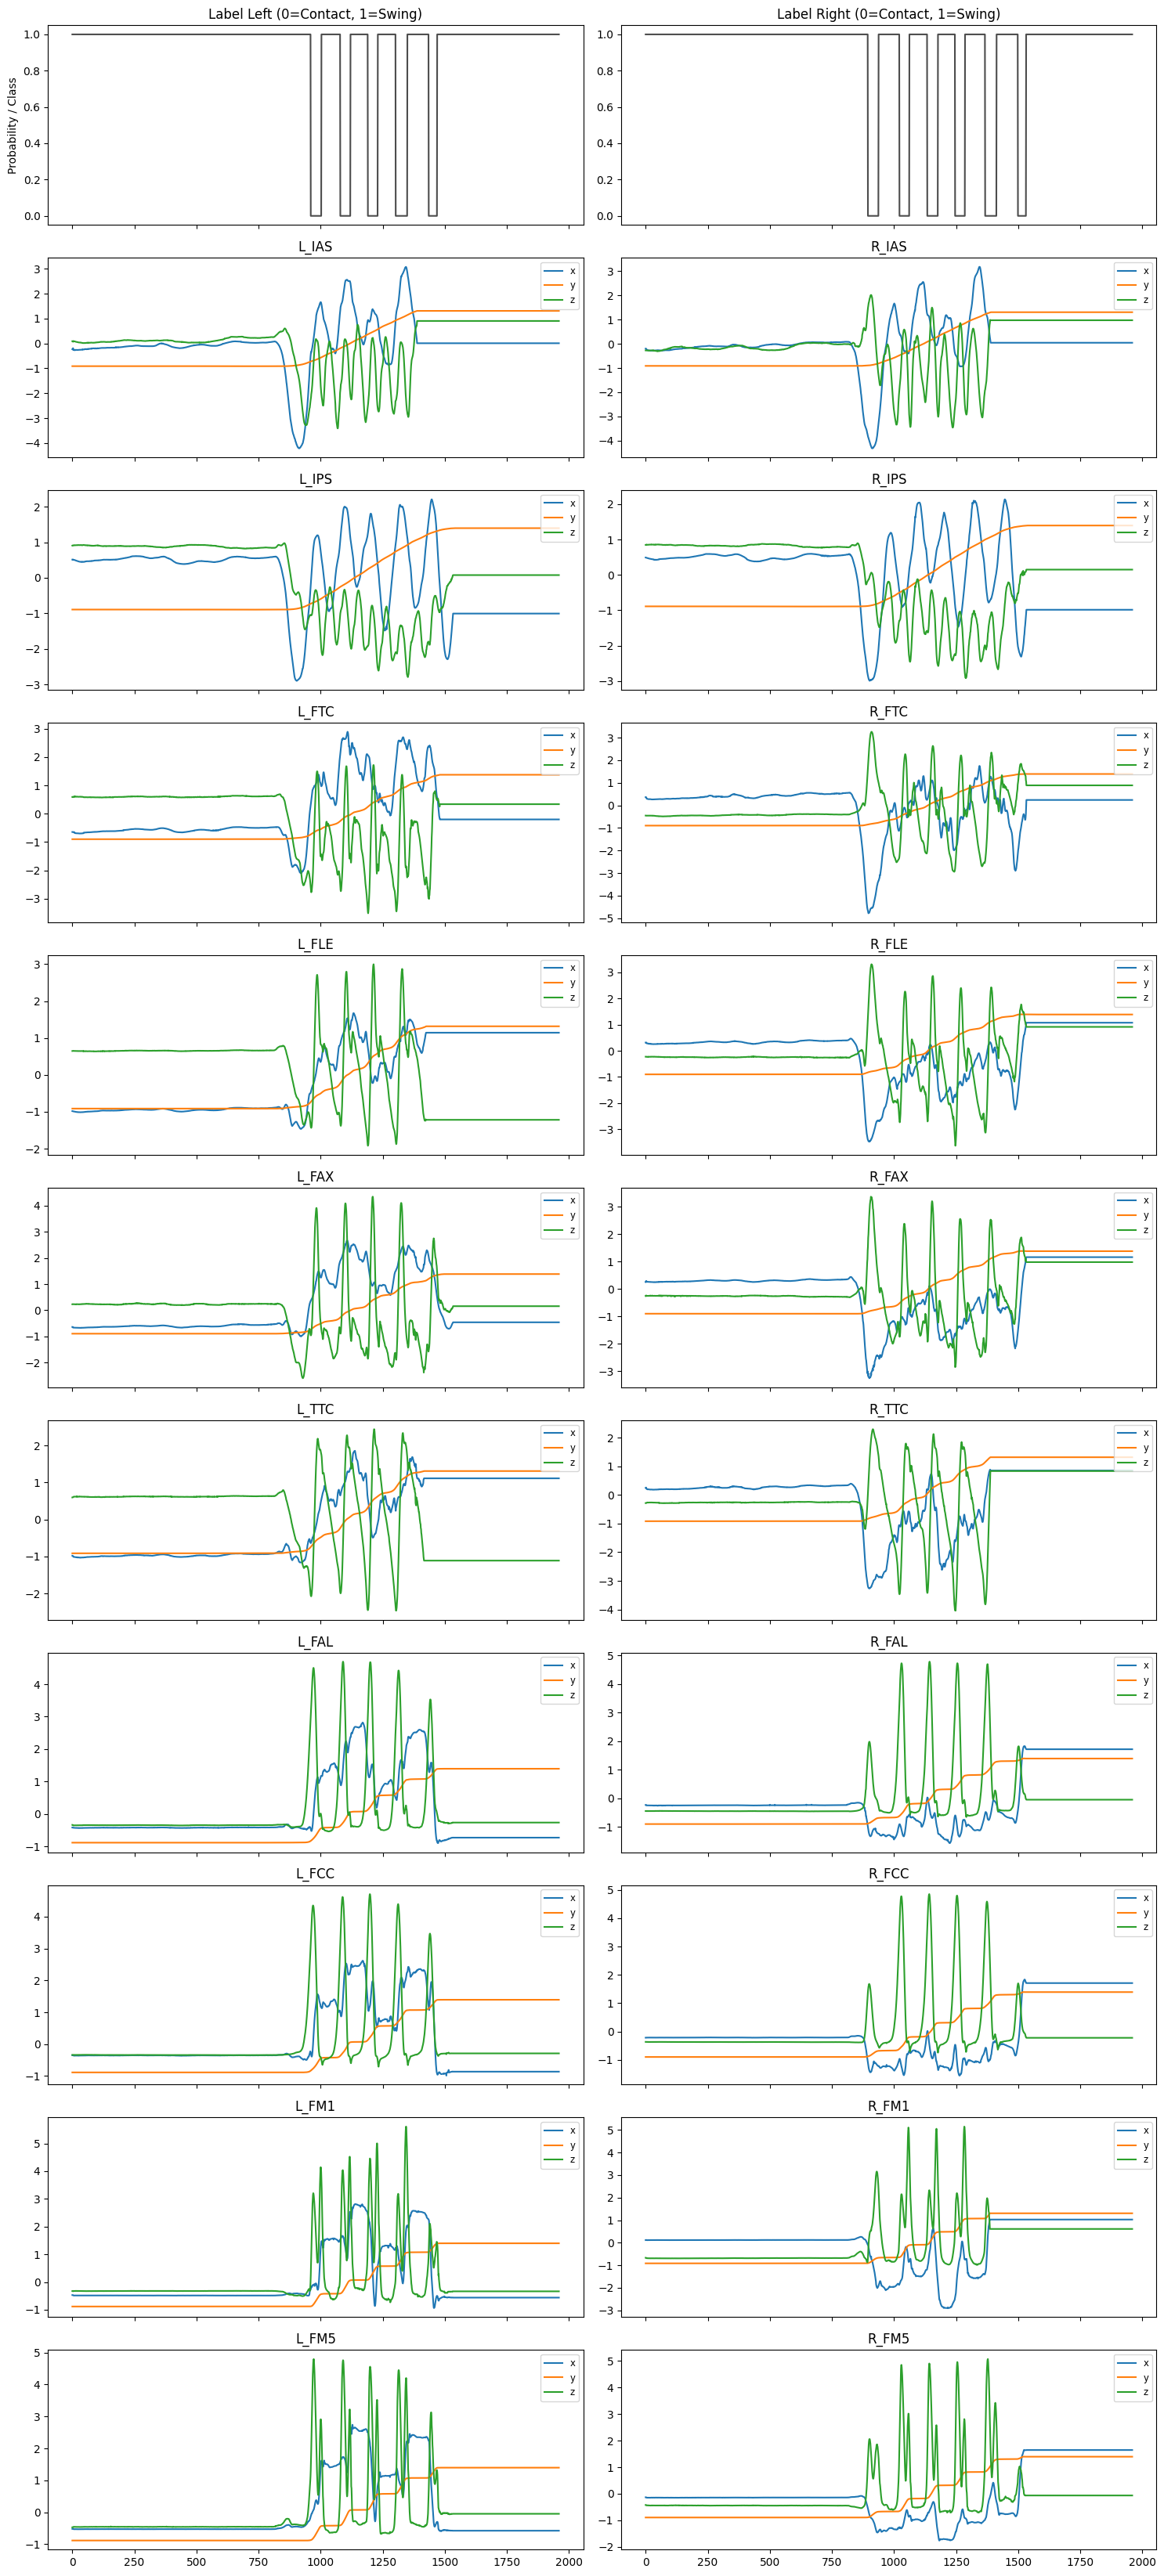

In [10]:
def plot_trial_2col(X_trial, Y_trial, sensor_names, n_pairs=3):
    # Identify pairs L_XXX / R_XXX
    pairs = []
    for i, name in enumerate(sensor_names):
        if name.startswith('L_'):
            suffix = name[2:]
            r_name = 'R_' + suffix
            if r_name in sensor_names:
                j = sensor_names.index(r_name)
                pairs.append((i, j, name, r_name))

    # Select the first n_pairs
    pairs = pairs[:n_pairs]

    # Plot
    n_rows = 1 + len(pairs)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 3*n_rows), sharex=True)

    # --- Row 0: Labels ---
    # Left Foot
    axes[0, 0].plot(Y_trial[:, 0], color='k', alpha=0.7)
    axes[0, 0].set_title("Label Left (0=Contact, 1=Swing)")
    axes[0, 0].set_ylabel("Probability / Class")

    # Right Foot
    axes[0, 1].plot(Y_trial[:, 1], color='k', alpha=0.7)
    axes[0, 1].set_title("Label Right (0=Contact, 1=Swing)")

    # --- Following Rows: Sensors ---
    for k, (idx_l, idx_r, name_l, name_r) in enumerate(pairs):
        row = k + 1

        # Left Sensor (3 axes)
        # Indices in flattened X: idx*3, idx*3+1, idx*3+2
        axes[row, 0].plot(X_trial[:, idx_l*3 : idx_l*3+3])
        axes[row, 0].set_title(f"{name_l}")
        axes[row, 0].legend(['x', 'y', 'z'], loc='upper right', fontsize='small')

        # Right Sensor (3 axes)
        axes[row, 1].plot(X_trial[:, idx_r*3 : idx_r*3+3])
        axes[row, 1].set_title(f"{name_r}")
        axes[row, 1].legend(['x', 'y', 'z'], loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

# Test on Subject 0, Trial 0
sensor_names = data['sensor_names']
print("Visualizing Subject 0, Trial 0:")
plot_trial_2col(X[0][0], Y[0][0], sensor_names, n_pairs=20)

## 4. Dynamic Cross-Validation and Data Augmentation

### Context

With only **10 subjects**, we need a validation strategy adapted to small datasets. We will implement a **dynamic cross-validation** (Leave-Subjects-Out):

- **5 folds** (to speed up; otherwise we could do 10)
- At each fold: **2 subjects in validation**, **2 subjects in test**, **6 subjects in train**
- Subject rotation: fold 0 → val=[0,1], test=[2,3], train=[4-9], etc.

### Limitations of Dynamic Cross-Validation

This approach is suitable for a **proof of concept** but has important limitations:

1. **We evaluate the model creation system**, not the final model itself
2. **Randomness may cause** the final model's training to not converge
3. **Hard to have a truly "unseen" test set** — temptation to cheat by adjusting hyperparameters after seeing results
4. **In production**, we can't use all these models — we must choose one

> **Best practice**: For real deployment, we would keep a completely separate test set from the start, never touched during development.

---

### Question 4: Implement the dataset creation function with cross-validation and data augmentation

Create a function `get_fold_datasets(X_dict, Y_dict, sensor_names, fold_idx, n_folds=5, batch_size=16)` that:

1. **Splits the 10 subjects** into train/val/test according to the fold (rotation: 6 train, 2 val, 2 test)
2. **Applies padding** up to `TARGET_LEN=2048` by repeating the last value
3. **Applies data augmentations on train** (see below)
4. **Returns 3 tf.data.Dataset**: `ds_train, ds_val, ds_test`

#### Data Augmentation (on train only)

**A. Left/Right Flip (NumPy, before Dataset creation):**
- Create a mirror copy of each sample by swapping L↔R sensors
- Invert the X coordinate (indices `[..., 0]` after reshape to `(T, n_sensors, 3)`)
- Invert the labels (channel 0 ↔ channel 1)
- Doubles the train set size

**B. Dynamic Augmentations (TensorFlow, via `.map()`):**

1. **Random Start Crop** (prob 1/3): Remove 0-500 samples from the beginning, then pad to TARGET_LEN with the last value (on both X and Y)

2. **Sensor Dropout** (prob 1/4): Zero out k random sensors (k∈[1,10]) for the entire duration

3. **Truncate & Hold** (prob 1/2): For k sensors (k∈[1,10]), freeze the signal and y from a random time t (t∈[1000, TARGET_LEN])

In [11]:
TARGET_LEN = 2048

def get_fold_datasets(X_dict, Y_dict, sensor_names, fold_idx, n_folds=5, batch_size=16):
    """
    Creates train/val/test datasets for a given fold with augmentation.
    """

    # 1. Split subjects
    n_subjects = 10
    val_subjects = [(2 * fold_idx) % n_subjects, (2 * fold_idx + 1) % n_subjects]
    test_subjects = [(2 * fold_idx + 2) % n_subjects, (2 * fold_idx + 3) % n_subjects]
    train_subjects = [s for s in range(n_subjects) if s not in val_subjects and s not in test_subjects]

    print(f"Fold {fold_idx}: Train {train_subjects}, Val {val_subjects}, Test {test_subjects}")

    # Helper: Load and Pad Data
    def load_data(subjects):
        X_list, Y_list = [], []
        for s in subjects:
            if s not in X_dict: continue
            for t in X_dict[s]:
                x = X_dict[s][t]
                y = Y_dict[s][t]

                # Pad to TARGET_LEN
                L = x.shape[0]
                if L < TARGET_LEN:
                    pad_len = TARGET_LEN - L
                    # Repeat last value
                    x_pad = np.tile(x[-1:], (pad_len, 1))
                    y_pad = np.tile(y[-1:], (pad_len, 1))
                    x_new = np.concatenate([x, x_pad], axis=0)
                    y_new = np.concatenate([y, y_pad], axis=0)
                else:
                    x_new = x[:TARGET_LEN]
                    y_new = y[:TARGET_LEN]

                X_list.append(x_new.astype(np.float32))
                Y_list.append(y_new.astype(np.float32))
        return np.array(X_list), np.array(Y_list)

    X_train, Y_train = load_data(train_subjects)
    X_val, Y_val = load_data(val_subjects)
    X_test, Y_test = load_data(test_subjects)

    # 2. Augmentation A: Left/Right Flip (NumPy) - Train Only
    # Identify sensor permutation
    perm = np.arange(len(sensor_names))
    for i, name in enumerate(sensor_names):
        if name.startswith('L_'):
            r_name = 'R_' + name[2:]
            if r_name in sensor_names:
                j = sensor_names.index(r_name)
                perm[i] = j
                perm[j] = i

    # Create flipped copy
    if len(X_train) > 0:
        n_tr, T, n_feat = X_train.shape
        X_aug = X_train.reshape(n_tr, T, 20, 3).copy()
        X_aug = X_aug[:, :, perm, :] # Permute sensors
        X_aug[:, :, :, 0] *= -1      # Invert X coordinate
        X_aug = X_aug.reshape(n_tr, T, n_feat)

        Y_aug = Y_train[:, :, ::-1]  # Swap labels (Left <-> Right)

        # Combine
        X_train = np.concatenate([X_train, X_aug], axis=0)
        Y_train = np.concatenate([Y_train, Y_aug], axis=0)

    print(f"  Train size: {X_train.shape[0]} trials (after flip)")

    # 3. Augmentation B: TensorFlow Functions
    def tf_augment(x, y):
        T = TARGET_LEN
        x = tf.reshape(x, (T, 20, 3))

        # Random Start Crop (p=1/3)
        if tf.random.uniform([]) < (1/3):
            crop = tf.random.uniform([], 0, 501, dtype=tf.int32)
            x_c = x[crop:]
            y_c = y[crop:]

            # Pad
            pad_sz = T - tf.shape(x_c)[0]
            x_pad = tf.repeat(x_c[-1:], pad_sz, axis=0)
            y_pad = tf.repeat(y_c[-1:], pad_sz, axis=0)

            x = tf.concat([x_c, x_pad], axis=0)
            y = tf.concat([y_c, y_pad], axis=0)

        # Sensor Dropout (p=1/4)
        if tf.random.uniform([]) < 0.25:
            k = tf.random.uniform([], 1, 11, dtype=tf.int32)
            indices = tf.random.shuffle(tf.range(20))[:k]

            mask = tf.ones((20,), dtype=x.dtype)
            mask = tf.tensor_scatter_nd_update(mask, indices[:, None], tf.zeros(k, dtype=x.dtype))
            x = x * tf.reshape(mask, (1, 20, 1))

        # Truncate & Hold (p=1/2)
        if tf.random.uniform([]) < 0.5:
            k = tf.random.uniform([], 1, 11, dtype=tf.int32)
            t = tf.random.uniform([], 1000, T, dtype=tf.int32)

            # Sensor mask (0 for frozen/selected)
            indices = tf.random.shuffle(tf.range(20))[:k]
            mask_s = tf.ones((20,), dtype=x.dtype)
            mask_s = tf.tensor_scatter_nd_update(mask_s, indices[:, None], tf.zeros(k, dtype=x.dtype))
            mask_s = tf.reshape(mask_s, (1, 20, 1))

            # Freeze Signal
            x_pre = x[:t]
            x_post = x[t:]
            val_t = tf.expand_dims(x[t], 0)
            # If mask=1 keep x_post, else use val_t
            x_post_fr = x_post * mask_s + val_t * (1 - mask_s)
            x = tf.concat([x_pre, x_post_fr], axis=0)

            # Freeze Y (global)
            y_pre = y[:t]
            y_post_fr = tf.repeat(tf.expand_dims(y[t], 0), T - t, axis=0)
            y = tf.concat([y_pre, y_post_fr], axis=0)

        x = tf.reshape(x, (T, 60))
        x = tf.ensure_shape(x, (T, 60))
        y = tf.ensure_shape(y, (T, 2))
        return x, y

    # 4. Create Datasets
    ds_train = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    ds_train = ds_train.shuffle(X_train.shape[0] if X_train.shape[0] > 0 else 1)
    ds_train = ds_train.map(tf_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds_train = ds_train.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    ds_val = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
    ds_val = ds_val.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    ds_test = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
    ds_test = ds_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds_train, ds_val, ds_test

---
## 5. Segmentation Models: U-Net, Bidirectional GRU, and SETR

We will implement and compare three architectures for temporal segmentation:

### 5.1 U-Net 1D

Classic encoder-decoder architecture with skip connections, adapted for 1D signals.

### 5.2 Bidirectional GRU

A recurrent approach using **Bidirectional Gated Recurrent Units**. The signal is processed by stacked GRU layers that read the sequence in both directions, followed by a CNN-based decoder to produce per-timestep predictions. This is a good baseline that can capture temporal dependencies without the complexity of a Transformer.

### 5.3 SETR (SEgmentation TRansformer)

**SETR** is based on the paper "Rethinking Semantic Segmentation from a Sequence-to-Sequence Perspective with Transformers" (CVPR 2021).

**Principle**: Rather than using convolutions (U-Net), SETR uses a **Transformer encoder** to capture long-range dependencies.

**Original architecture** (for images):

1. The image is split into patches
2. Each patch is projected to a vector (embedding)
3. A Transformer encoder processes the sequence of patches
4. A decoder reconstructs the segmentation

**Decoder variants**:
- **SETR-Naive**: Simple reshape without upsampling
- **SETR-PUP**: Progressive Upsampling
- **SETR-MLA**: Multi-Level feature Aggregation

**Our 1D adaptation**:

In our case, the output must have the **same temporal dimension as the input** (many-to-many). We adopt a simplified approach:

1. **Patchify**: Split the signal into temporal patches (e.g., 2048 → 256 patches of size 8)
2. **Linear Embedding**: Project each patch to the latent space
3. **Positional Embedding**: Add position information
4. **Transformer Encoder**: 12 multi-head attention blocks
5. **Segmentation Head**: Each token predicts labels for all points in its patch

The key idea is that each **Transformer token** contains contextual information from **the entire signal** thanks to the attention mechanism, allowing precise predictions for its temporal zone.

### Question 5.1: Implement the U-Net 1D model

In [28]:
def get_unet_model(input_shape=(2048, 60), n_classes=2):
    inputs = Input(shape=input_shape)

    def encoder_block(x, filters):
        x = Conv1D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv1D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = MaxPooling1D(2)(x)
        return x

    def decoder_block(x, skip, filters):
        x = UpSampling1D(2)(x)
        x = Conv1D(filters, 2, padding='same')(x)
        x = Concatenate()([x, skip])
        x = Conv1D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv1D(filters, 3, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        return x

    # Encoder (4 levels used)
    s1 = encoder_block(inputs, 32)   # 2048 -> 1024
    s2 = encoder_block(s1, 64)       # 1024 -> 512
    s3 = encoder_block(s2, 128)      # 512 -> 256
    s4 = encoder_block(s3, 256)      # 256 -> 128
    s5 = encoder_block(s4, 512)      # 128 -> 64


    # Bottleneck
    b = Conv1D(512, 3, padding='same')(s5)
    b = BatchNormalization()(b)
    b = Activation('relu')(b)
    b = Conv1D(512, 3, padding='same')(b)
    b = BatchNormalization()(b)
    b = Activation('relu')(b)



    # Decoder (matching 5 levels)
    d1 = decoder_block(b, s4, 256)
    d2 = decoder_block(d1, s3, 256)       # 128 -> 256
    d3 = decoder_block(d2, s2, 128)      # 256 -> 512
    d4 = decoder_block(d3, s1, 64)       # 512 -> 1024
    d5 = decoder_block(d4, inputs, 32)       # 1024 -> 2048 (Output size reached)

    # Output
    outputs = Conv1D(n_classes, 1, activation='sigmoid')(d5)

    model = Model(inputs, outputs, name="UNet1D")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    return model

model_unet = get_unet_model()
model_unet.summary()

Model: "UNet1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 2048, 60)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_329 (Conv1D) │ (None, 2048, 32)  │      5,792 │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048, 32)  │        128 │ conv1d_329[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_272      │ (None, 2048, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_330 (Conv1D) │ (None, 2048, 32)  │      3,104 │ activation_272[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048, 32)  │        128 │ conv1d_330[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_273      │ (None, 2048, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_79    │ (None, 1024, 32)  │          0 │ activation_273[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_331 (Conv1D) │ (None, 1024, 64)  │      6,208 │ max_pooling1d_79… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 64)  │        256 │ conv1d_331[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_274      │ (None, 1024, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_332 (Conv1D) │ (None, 1024, 64)  │     12,352 │ activation_274[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 64)  │        256 │ conv1d_332[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_275      │ (None, 1024, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_80    │ (None, 512, 64)   │          0 │ activation_275[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_333 (Conv1D) │ (None, 512, 128)  │     24,704 │ max_pooling1d_80… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv1d_333[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_276      │ (None, 512, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,897,698 (18.68 MB)

 Trainable params: 4,888,738 (18.65 MB)

 Non-trainable params: 8,960 (35.00 KB)

### Question 5.2: Implement the Bidirectional GRU model

Build a model using **Bidirectional GRU** layers followed by a convolutional decoder. Architecture:

1. **Optional Conv1D front-end** (e.g. 1-2 conv layers for feature extraction)
2. **2 stacked Bidirectional GRU layers** (e.g. 128 units each, `return_sequences=True`)
3. **Conv1D decoder** to project back to `n_classes` with sigmoid activation

This model processes the entire sequence bidirectionally and outputs a per-timestep prediction.

In [29]:
def get_gru_model(input_shape=(2048, 60), n_classes=2):
    inputs = Input(shape=input_shape)

    # 1. Optional Conv1D front-end
    x = Conv1D(64, 3, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    # 2. Stacked Bidirectional GRU layers
    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # 3. Conv1D decoder
    x = Conv1D(64, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Output projection
    outputs = Conv1D(n_classes, 1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="BiGRU")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    return model

model_gru = get_gru_model()
model_gru.summary()

Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 2048, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_357 (Conv1D)             │ (None, 2048, 64)       │        11,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_294         │ (None, 2048, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_294 (Activation)     │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 2048, 256)      │       148,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_295         │ (None, 2048, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 2048, 256)      │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_296         │ (None, 2048, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_358 (Conv1D)             │ (None, 2048, 64)       │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_297         │ (None, 2048, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_295 (Activation)     │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_359 (Conv1D)             │ (None, 2048, 2)        │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 508,930 (1.94 MB)

 Trainable params: 507,650 (1.94 MB)

 Non-trainable params: 1,280 (5.00 KB)

### Question 5.3: Implement the SETR model

In [30]:
def get_setr_model(input_shape=(2048, 60), n_classes=2, patch_size=8, d_model=128, num_layers=6, num_heads=4):
    inputs = Input(shape=input_shape)

    # 1. Patchify
    # Reshape (B, T, F) -> (B, N_patches, patch_size * F)
    num_patches = input_shape[0] // patch_size
    patch_dim = input_shape[1] * patch_size

    x = Reshape((num_patches, patch_dim))(inputs)

    # 2. Linear Projection to latent space
    x = Dense(d_model)(x)

    # 3. Add Positional Embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_emb = Embedding(input_dim=num_patches, output_dim=d_model)(positions)
    x = x + pos_emb

    # 4. Transformer Encoder Blocks
    for _ in range(num_layers):
        # Attention Block
        x_norm = LayerNormalization(epsilon=1e-6)(x)
        attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)(x_norm, x_norm)
        x = Add()([x, attn_out])

        # FFN Block
        x_norm = LayerNormalization(epsilon=1e-6)(x)
        ffn_out = Dense(d_model * 2, activation='gelu')(x_norm)
        ffn_out = Dropout(0.1)(ffn_out)
        ffn_out = Dense(d_model)(ffn_out)
        ffn_out = Dropout(0.1)(ffn_out)
        x = Add()([x, ffn_out])

    # 5. Segmentation Head
    x = LayerNormalization(epsilon=1e-6)(x)
    x = Dense(patch_size * n_classes)(x)

    # Reshape to original temporal length
    outputs = Reshape((input_shape[0], n_classes))(x)
    outputs = Activation('sigmoid')(outputs)

    model = Model(inputs, outputs, name="SETR")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    return model

model_setr = get_setr_model()
model_setr.summary()

Model: "SETR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 2048, 60)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 256, 480)  │          0 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 128)  │     61,568 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256, 128)  │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ add_2[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256, 256)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256, 128)  │     32,896 │ dropout_7[0][0] 

 Total params: 858,768 (3.28 MB)

 Trainable params: 858,768 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Training and Comparison on 5 Folds

### Question 6.1: Train all three models on 5 folds and compare val_loss

**IMPORTANT: For each fold, you must save the best model for each architecture** (based on `val_loss`) using `ModelCheckpoint` with `save_best_only=True`. This means each fold produces one saved model per architecture. At the end, you should have **5 saved models per architecture** (one per fold), for a total of **15 saved model files**.

This is essential for later evaluation: each fold's best model is tested on its corresponding held-out test set.

In [31]:
N_FOLDS = 5
EPOCHS = 100  # Keeping it short for demonstration. Increase for better results.

# To store results if needed later
histories = {'unet': [], 'gru': [], 'setr': []}

for fold_idx in range(N_FOLDS):
    print(f"\n{'='*60}")
    print(f"STARTING FOLD {fold_idx}/{N_FOLDS-1}")
    print(f"{'='*60}")

    # 1. Get Datasets
    ds_train, ds_val, ds_test = get_fold_datasets(X, Y, sensor_names, fold_idx, n_folds=N_FOLDS)

    # 2. Train U-Net
    print(f"\n--- Training U-Net (Fold {fold_idx}) ---")
    tf.keras.backend.clear_session()
    model_unet = get_unet_model()

    ckpt_unet = ModelCheckpoint(
        f'unet_fold{fold_idx}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    hist = model_unet.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=[ckpt_unet],
        verbose=1
    )
    histories['unet'].append(hist.history)
    del model_unet

    # 3. Train BiGRU
    print(f"\n--- Training BiGRU (Fold {fold_idx}) ---")
    tf.keras.backend.clear_session()
    model_gru = get_gru_model()

    ckpt_gru = ModelCheckpoint(
        f'gru_fold{fold_idx}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    hist = model_gru.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=[ckpt_gru],
        verbose=1
    )
    histories['gru'].append(hist.history)
    del model_gru

    # 4. Train SETR
    print(f"\n--- Training SETR (Fold {fold_idx}) ---")
    tf.keras.backend.clear_session()
    model_setr = get_setr_model()

    ckpt_setr = ModelCheckpoint(
        f'setr_fold{fold_idx}.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    hist = model_setr.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=[ckpt_setr],
        verbose=1
    )
    histories['setr'].append(hist.history)
    del model_setr

print("\nAll folds processed!")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
Epoch 63: val_loss did not improve from 0.02333
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6692 - loss: 0.0437 - val_accuracy: 0.8125 - val_loss: 0.0289
Epoch 64/100
5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7280 - loss: 0.0878 
Epoch 64: val_loss did not improve from 0.02333
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7303 - loss: 0.0820 - val_accuracy: 0.7295 - val_loss: 0.0279
Epoch 65/100
5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5790 - loss: 0.0411 
Epoch 65: val_loss did not improve from 0.02333
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5583 - loss: 0.0390 - val_accuracy: 0.7994 - val_loss: 0.0288
Epoch 66/100
5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6666 - loss: 0.0880 
Epoch 66: val_loss did not improve from 0.02333
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6277 - loss: 0.0822 - val_accuracy: 0.5585 - val_loss: 0.0430
Epoch 67/100
5/8

### Question 6.2: Evaluate all models on their respective test sets

For each fold, load the best saved model for each architecture and evaluate on the corresponding test set. Report the average test loss and accuracy across folds.

In [32]:
from tensorflow.keras.models import load_model
import numpy as np
import os

results = {'UNet1D': [], 'BiGRU': [], 'SETR': []}
model_files = {
    'UNet1D': 'unet_fold{}.keras',
    'BiGRU': 'gru_fold{}.keras',
    'SETR': 'setr_fold{}.keras'
}

for fold_idx in range(N_FOLDS):
    print(f"\nEvaluating Fold {fold_idx}...")

    # Get test data
    # We only need ds_test here
    _, _, ds_test = get_fold_datasets(X, Y, sensor_names, fold_idx, n_folds=N_FOLDS, batch_size=16)

    for name, file_pattern in model_files.items():
        filepath = file_pattern.format(fold_idx)
        if os.path.exists(filepath):
            # Load model
            # Note: Custom layers like MultiHeadAttention usually load fine in recent TF versions.
            try:
                model = load_model(filepath)
            except Exception as e:
                print(f"  Error loading {filepath}: {e}")
                continue

            # Recompile to ensure we use 'binary_accuracy' specifically as requested
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

            loss, acc = model.evaluate(ds_test, verbose=0)
            results[name].append((loss, acc))
            print(f"  {name}: Loss={loss:.4f}, Acc={acc:.4f}")
        else:
            print(f"  {name}: Model file not found ({filepath})")

print("\n" + "="*40)
print("AVERAGE RESULTS ACROSS FOLDS")
print("="*40)

for name, res_list in results.items():
    if len(res_list) > 0:
        avg_loss = np.mean([r[0] for r in res_list])
        avg_acc = np.mean([r[1] for r in res_list])
        print(f"{name:10s} | Avg Loss: {avg_loss:.4f} | Avg Acc: {avg_acc:.4f}")
    else:
        print(f"{name:10s} | No results found.")


Evaluating Fold 0...
Fold 0: Train [4, 5, 6, 7, 8, 9], Val [0, 1], Test [2, 3]
  Train size: 118 trials (after flip)
  UNet1D: Loss=0.0248, Acc=0.9934
  BiGRU: Loss=0.0203, Acc=0.9938
  SETR: Loss=0.0193, Acc=0.9941

Evaluating Fold 1...
Fold 1: Train [0, 1, 6, 7, 8, 9], Val [2, 3], Test [4, 5]
  Train size: 116 trials (after flip)


  UNet1D: Loss=0.0249, Acc=0.9936


  BiGRU: Loss=0.0150, Acc=0.9949
  SETR: Loss=0.0177, Acc=0.9943

Evaluating Fold 2...
Fold 2: Train [0, 1, 2, 3, 8, 9], Val [4, 5], Test [6, 7]
  Train size: 112 trials (after flip)
  UNet1D: Loss=0.0290, Acc=0.9928
  BiGRU: Loss=0.0271, Acc=0.9927
  SETR: Loss=0.0252, Acc=0.9925

Evaluating Fold 3...
Fold 3: Train [0, 1, 2, 3, 4, 5], Val [6, 7], Test [8, 9]
  Train size: 112 trials (after flip)
  UNet1D: Loss=0.0272, Acc=0.9941
  BiGRU: Loss=0.0173, Acc=0.9948
  SETR: Loss=0.0210, Acc=0.9932

Evaluating Fold 4...
Fold 4: Train [2, 3, 4, 5, 6, 7], Val [8, 9], Test [0, 1]
  Train size: 112 trials (after flip)
  UNet1D: Loss=0.0339, Acc=0.9905
  BiGRU: Loss=0.0241, Acc=0.9927
  SETR: Loss=0.0227, Acc=0.9919

AVERAGE RESULTS ACROSS FOLDS
UNet1D     | Avg Loss: 0.0280 | Avg Acc: 0.9929
BiGRU      | Avg Loss: 0.0207 | Avg Acc: 0.9938
SETR       | Avg Loss: 0.0212 | Avg Acc: 0.9932


---
## 7. Prediction Visualization

Display predictions vs ground truth for a few test trials.

Loading models for visualization...
Fold 0: Train [4, 5, 6, 7, 8, 9], Val [0, 1], Test [2, 3]
  Train size: 118 trials (after flip)


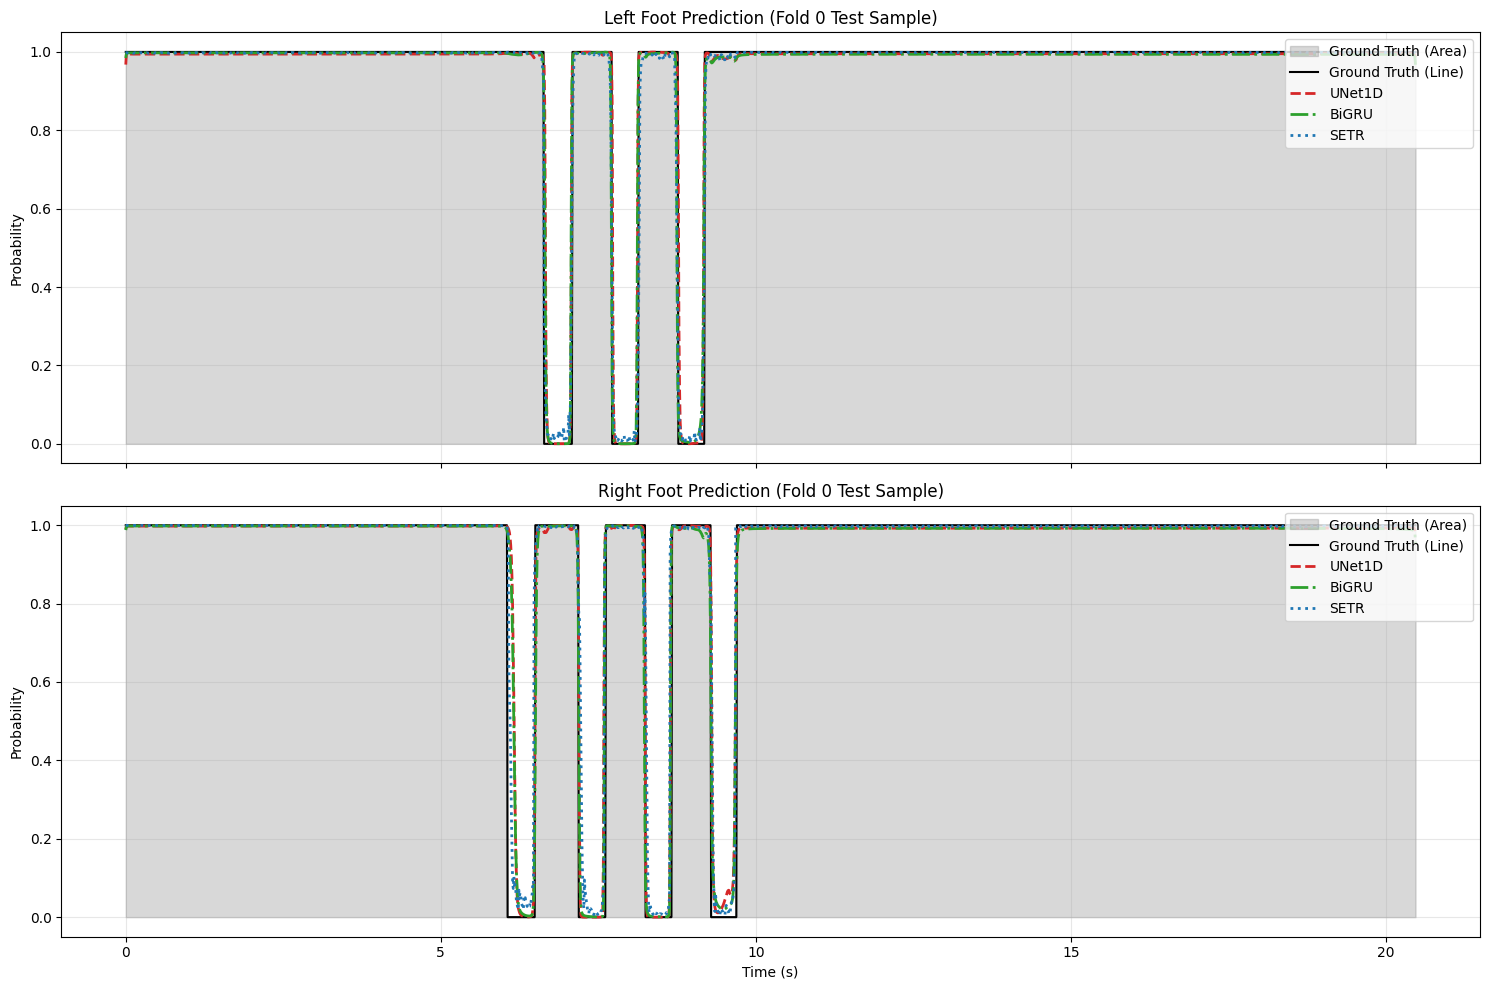

In [33]:
# 1. Load models for Fold 0
fold_idx = 0
models_viz = {}
model_map = {
    'UNet1D': f'unet_fold{fold_idx}.keras',
    'BiGRU': f'gru_fold{fold_idx}.keras',
    'SETR': f'setr_fold{fold_idx}.keras'
}

print("Loading models for visualization...")
for name, path in model_map.items():
    if os.path.exists(path):
        try:
            models_viz[name] = load_model(path)
            # Recompile to avoid warnings
            models_viz[name].compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
        except Exception as e:
            print(f"Could not load {name}: {e}")

# 2. Get a sample from Fold 0 Test Set
# Use batch_size=1 to easily grab single trials
_, _, ds_test_viz = get_fold_datasets(X, Y, sensor_names, fold_idx, n_folds=N_FOLDS, batch_size=1)

# Take the first example
iterator = iter(ds_test_viz)
X_sample, Y_sample = next(iterator)

# 3. Predict
preds = {}
for name, model in models_viz.items():
    p = model.predict(X_sample, verbose=0)
    preds[name] = p[0]  # Remove batch dim

Y_true = Y_sample[0].numpy()

# 4. Plot
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
time_axis = np.arange(2048) / 100.0  # 100 Hz -> seconds

colors = {'UNet1D': 'tab:red', 'BiGRU': 'tab:green', 'SETR': 'tab:blue'}
linestyles = {'UNet1D': '--', 'BiGRU': '-.', 'SETR': ':'}

# Left Foot
axes[0].fill_between(time_axis, 0, Y_true[:, 0], color='gray', alpha=0.3, label='Ground Truth (Area)')
axes[0].plot(time_axis, Y_true[:, 0], 'k', linewidth=1.5, label='Ground Truth (Line)')
for name, p in preds.items():
    axes[0].plot(time_axis, p[:, 0], color=colors[name], linestyle=linestyles[name], linewidth=2, label=name)
axes[0].set_title(f"Left Foot Prediction (Fold {fold_idx} Test Sample)")
axes[0].set_ylabel("Probability")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Right Foot
axes[1].fill_between(time_axis, 0, Y_true[:, 1], color='gray', alpha=0.3, label='Ground Truth (Area)')
axes[1].plot(time_axis, Y_true[:, 1], 'k', linewidth=1.5, label='Ground Truth (Line)')
for name, p in preds.items():
    axes[1].plot(time_axis, p[:, 1], color=colors[name], linestyle=linestyles[name], linewidth=2, label=name)
axes[1].set_title(f"Right Foot Prediction (Fold {fold_idx} Test Sample)")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Time (s)")
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Subject-Specific Fine-Tuning with LoRA

### Context

**LoRA (Low-Rank Adaptation)** is a technique originally proposed for fine-tuning large language models, but applicable to any neural network. The idea is to freeze the pretrained weights and inject **small trainable low-rank matrices** into specific layers.

For a weight matrix $W \in \mathbb{R}^{d \times k}$, LoRA decomposes the update as:

$$W' = W + \Delta W = W + B \cdot A$$

where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$ with rank $r \ll \min(d, k)$.

**Why LoRA for per-subject adaptation?**

In medical applications, each patient may have a slightly different gait pattern. A model trained on the general population might benefit from a small per-subject adaptation. LoRA allows this with very few additional parameters.

### Pedagogical Note

In this exercise, we use **rank r=1** and only train on **3 trials** per subject (trials 0-2), validating on trials 3-4 and testing on trials 5-9.

**In reality, this number of repetitions is not sufficient for LoRA to have a meaningful impact.** The training data is too limited for per-subject adaptation to generalize well. This section is purely **pedagogical** — its purpose is to teach you the LoRA concept and implementation, not to demonstrate real gains. In a real clinical setting, you would need many more trials per subject.

### Question 8: Implement LoRA fine-tuning on SETR

For **fold 0** only (subjects 0 and 1 as validation subjects):

1. Load the pretrained SETR model from fold 0
2. Implement a `LoRADense` layer that wraps a Dense layer with low-rank adaptation (rank=1)
3. Apply LoRA to the Transformer's feed-forward Dense layers
4. For **subject 0** and **subject 1** independently:
   - Train: trials 0-2
   - Validation: trials 3-4
   - Test: trials 5-9
5. Compare test performance **with** and **without** LoRA

In [ ]:
# ===== YOUR CODE HERE =====
